# Statistical Inference for Linear Regression Lab

## Introduction

Imagine you are a junior data scientist working for a real estate analytics firm. Your team is tasked with understanding how median income levels across neighborhoods affect housing prices. The company is developing a pricing model to help real estate investors make data-driven decisions. As a first step, your manager asks you to analyze the relationship between Median Income (MedInc) and Median House Value (MedianHouseValue) using a simple linear regression model.

Understanding the relationship between income levels and housing prices is crucial in various industries, including real estate investment, urban planning, and mortgage risk assessment.

By completing this lab, you will gain hands-on experience in applying regression analysis to a real-world problem, strengthening your ability to build predictive models for business decision-making.

### Step 0

Load the appropriate libraries and bring in the data. Note that we have to run a script to get the [California Housing dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html) to match the version in `scikit-learn`. We cannot pull it directly from `scikit-learn` since CodeGrade cannot access the internet.

In [1]:
# CodeGrade step0

from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import os
import tarfile
import joblib # Import joblib directly
from sklearn.datasets._base import _pkl_filepath, get_data_home
import statsmodels.api as sm

# Process to get the data to match the version in scikit-learn:
archive_path = "cal_housing.tgz" # Change the path if it's not in the current directory.
data_home = get_data_home(data_home=None) # Change data_home if you are not using ~/scikit_learn_data.
if not os.path.exists(data_home):
    os.makedirs(data_home)
filepath = _pkl_filepath(data_home, "cal_housing.pkz")

with tarfile.open(mode = "r:gz", name = archive_path) as f:
    cal_housing = np.loadtxt(
                            f.extractfile("CaliforniaHousing/cal_housing.data"),
                            delimiter = ",")
    # Columns are not in the same order compared to the previous URL resource
    # on lib.stat.cmu.edu:
    columns_index = [8, 7, 2, 3, 4, 5, 6, 1, 0]
    cal_housing = cal_housing[:, columns_index]

    joblib.dump(cal_housing, filepath, compress=6) # Now using the directly imported joblib.

# Load the dataset:
california = fetch_california_housing(as_frame = True)
data = california.data
target = california.target

### Step 1

- Create a copy of the data and call it `df`.
- Select the `X` variable to be `MedInc` as a single-column DataFrame and the `y` to be `MedianHouseValue`.
- Add the constant term and call it `X_const`.

Verify this by returning the shape of `X_const`.

In [2]:
# CodeGrade step1

df = data.copy()
X = df[["MedInc"]]
y = target

# Add a constant for the y-intercept term, so that the model doesn't force the
# line through the origin:
X_const = sm.add_constant(X)

X_const.shape

(20640, 2)

### Step 2

Fit the OLS model and call it `model`.

Then return the rounded model $r^2$ value to four decimal places.

In [3]:
# CodeGrade step2

# Create the linear regression model using the Ordinary Least Squares (OLS)
# method:
model = sm.OLS(y, X_const).fit()

r_squared = round(model.rsquared, 4)
r_squared

0.4734

Print the model summary.

In [4]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.473
Method:                 Least Squares   F-statistic:                 1.856e+04
Date:                Mon, 14 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:46:23   Log-Likelihood:                -25623.
No. Observations:               20640   AIC:                         5.125e+04
Df Residuals:                   20638   BIC:                         5.127e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.4509      0.013     34.082      0.0

### Step 3

Extract the slope and the related statistics for `MedInc`, calling them, respectively, `slope`, `std_error`, `t_statistic`, and `p_value`.

Return the following (do not round) to verify: `slope, std_error, t_statistic, p_value`.

In [5]:
# CodeGrade step3

slope = model.params["MedInc"]
std_error = model.bse["MedInc"]
t_statistic = model.tvalues["MedInc"]
p_value = model.pvalues["MedInc"]

slope, std_error, t_statistic, p_value

(0.41793849201896605, 0.003068057538867864, 136.22250779989884, 0.0)

### Step 4

Calculate the confidence interval for the slope of `MedInc` at a 95% level of confidence, and call this `conf_int`.

Return the confidence interval rounded to four decimal places.

In [6]:
# CodeGrade step4

conf_int = model.conf_int().loc["MedInc"].round(4)

conf_int

0    0.4119
1    0.4240
Name: MedInc, dtype: float64

### Step 5

Find the model predictions and call them `y_pred`.

Return `y_pred.shape` to verify.

In [7]:
# CodeGrade step5

# Generate predicted values for the regression line:
y_pred = model.predict(X_const)

y_pred.shape

(20640,)

Plot the scatterplot with the regression line.

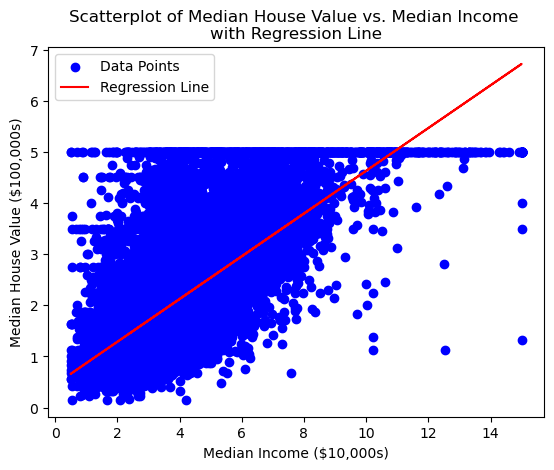

In [8]:
plt.scatter(x = X, y = y, color = "blue", label = "Data Points")
plt.plot(X, y_pred, color = "red", label = "Regression Line")
plt.title("Scatterplot of Median House Value vs. Median Income \nwith " \
          "Regression Line")
plt.xlabel("Median Income ($10,000s)")
plt.ylabel("Median House Value ($100,000s)")
plt.legend()
plt.show()